# FINAL PROJECT: PORTFOLIO TESTING PLATFORM
## FA 595: Financial Technology (Fall 2022)
## By: John Markin and Veronica Abramson

## Introduction

### Robo Advisors
#### What are they?

- Digital wealth investmnet platforms
    - Automatically balance your portfolio
    - Offer a low-dee, hands off investing approach
    - Automatic rebalancing
    - Tax optimization (or Tax-loss Harvesting)
        - Offset taxable income by deliberately incurring losses
    
- Wealthfront and Betterment 
    - Modern Portfolio Theory
    - May differ in policies for fees, account minimums, additional services, etc.

### Objective

- Extend our previous submission of Robo Advisor mini project
    - Ask user series of questions to create asset allocation
    - Interactive component for unique user experience
    
- Process:
    - Ask user a series of questions
    - Estimate risk parameter
    - Set bounds for assets (or user can do this manually)
    - Input time horizon
    - Target return
    - Plot Efficient Frontier

## Methodology

- The goal of the project is to estimate the risk parameter for investors.
- Based on Wealthfront cost effective methodology
    - Set values and weights
    - Estimate portfolio boundaries
- Assets selected based on all ETFs in US market
- Algorithm based on Wealthfront strategy to choose ETFs
- Estimate return from -100% to 100%
- Calculate minimum volatility
- Option for user to create own questions and weights

Below are the packages required to run our code.

In [3]:
## Loading Packages
import pandas as pd
import numpy as np
import requests, lxml
from lxml import html
from datetime import datetime
import time
from bs4 import BeautifulSoup
import math 
import statistics
import calendar

pd.core.common.is_list_like = pd.api.types.is_list_like
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from numpy.linalg import inv
from cvxopt import matrix, solvers 
from numpy import c_
import datetime as dt
from scipy.optimize import minimize 
from tkinter import messagebox, ttk
import tkinter as tk


from pandas_datareader import data as pdr
from datetime import datetime,date
#pip install yfinance
import yfinance as yf
yf.pdr_override()

/Users/johnmarkin/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Below is a function that allows user to set their own questions and weights for the answers to those questions. This gives the user an opportunity to cater our robo-advisor to their specific needs. If the user is not interested in this option, they can use our sample list of questions and answers below.

In [4]:
def questions():
    
    '''
    This code basically allows user to write their own questions and assign wieghts
    The basic syntax is the string with answer choices and their wieght
    n = the number of answer choices for the question 
    '''
    
    q = str(input("Type Question : "))
    while True:
        try:
            n = int(input("Type Number of Answer Choices : "))
        except ValueError:
            print("Sorry, I didn't understand that.")
                #better try again... Return to the start of the loop
            continue
        else:
            break
    
    answers = {}
    for i in range(n):
        category = str(input("Answer: "))
        while True:
            try:
                ans = float(input("Weight of the answer : "))
            except ValueError:
                print("Sorry, I didn't understand that.")
                    #better try again... Return to the start of the loop
                continue
            else:
                break
        
        answers[category]  = ans
        
    print("Success! Please type your next set of questions and answers. If you are finished, please press the 'interrupt the kernel' button at the top of Jupyter Notebook.")
    return {q:answers}

In [5]:
selection = ''
para = ''
def selc_val(i):
    '''
    This function displays a combo box for you to input the selected values
    '''
    # 
    x = l[i]
    def display_selection():
        global selection
        global para
        global x
        # Get the selected value.
        selection =combo.get()
        para = combo.current()
        messagebox.showinfo(
                   message=f"The selected value is: {selection}",
                title="Selection"
            )

    main_window = tk.Tk()
    main_window.config(width=500, height=300)
    main_window.title(list(x.keys())[0])
    combo = ttk.Combobox(
            state="readonly",
            values=list(list(x.values())[0].keys())
        )

    combo.place(x=50, y=50)
    button = ttk.Button(text="Submit", command=display_selection)
    button.place(x=50, y=100)
    main_window.mainloop()
    
    return para

Below are the sample list of questions and weights of answers.

- Important factors to consider:
    - age
    - yearly income
    - current liquid assets
    - goal of investment portfolio
    - risk tolerance

In [6]:
#USE THIS AS A SAMPLE
l = [ {'How old are you?': {'18 - 24': 0.9,
   '25 - 30': 0.7,
   '31 - 34': 0.55,
   '35 - 40': 0.45,
   '41 - 50': 0.4,
   '50+': 0.3}},
 {'How much do you make yearly? (Annual Before Tax)': 
  {'Up to $25,000': 0.3,
   '$25,000 - $50,000': 0.4,
   '$50,000 - $75,000': 0.55,
   '$75,000 - $100,000': 0.6,
   '$100,000 - $150,000': 0.65,
   '$150,000 - $200,000': 0.75,
   'More than $200,000': 0.85}},
 {'How much do you have in cash or assets that can easily be converted into cash? (Liquidity)': 
  {'Up to $50,000': 0.25,
   '$50,000 - $100,000': 0.55,
   '$100,000 - $250,000': 0.65,
   '$250,000 - $500,000': 0.75,
   'More than $500,000': 0.9}},
 {'What do you expect from your investments? (Main goal as an investor)': 
  {'I want to grow savings with low risk': 0.25,
   'Something in Between ': 0.5,
   'I want to grow my savings as much as possible': 0.9}},
 {'Imagine you started with a $10,000 investment. Then, in one month, your investment lost $1,000 in value. What would you do next?': {"I'd sell everything": 0.1,
   "I'd sell some": 0.35,
   "I'd do nothing": 0.5,
   "I'd buy more": 0.8}}]


In [ ]:
# This allows you to create questions.
l = []
numberq = 5
for i in range(numberq):
    l.append(questions())

Now, the code below will allow a user to answer all of the questions they defined above with the answers they provided. This will translate as the user's risk prreferences and estimate their risk aversion in the asset allocation below. Once you have selected your answer choice, click the "Submit" button below your selection and close the dialog box. The next one will then pop up.

In [27]:
allriskval = []
for i in range(5):
    allriskval.append(list(list(l[i].values())[0].values())[selc_val(i)])
    

In [28]:
#print the risk aversion parameter
np.sum(allriskval) 

3.0500000000000003

## Wealthfront Cost Effective Methodology
### Used for Asset Selection

Our method for asset selection is based on Wealthfront cost effective methodology.

The program uses ETF's that provide cost benefits compared to investing in whole stocks or mutual funds. With this in mind our asset selection criteria are:

1. We select the lowest ETF based on expense ratio

    - retrieve current expense rates from yahoo finance using a web scrapper


2. Volume

    - the higher the liquidity of the ETF, the more efficeint sales and purchases made
    - Yahoo finance provides the current average trading volume


3. Tracking error of the ETF

    - tracking error can be seen as variance from a selected benchmark (tracking error)
    - higher tracking error means ETF is less likely to represent its asset class
    - lower tracking error is preferable


### Algorithm for Asset Selection

In [8]:
## Define url for scraping 
def assetdetails(etf,bench,start,end):
    '''
    This function scrapes yahoo finance for the expense ratio, volume , pulls 
    out the ETF's adjusted prices and computes the tracking error. 
    
    '''
    
    # type the etf as string
    etf = etf
    #join the url with the string
    items = ("https://finance.yahoo.com/quote/",etf,"/profile?p=",etf)
    url = "".join(items)
    
    
    ## Pull the data from the website using beautiful soup package
    r = requests.get(url,headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.text,'html.parser')
    
    #------------
    # locate the data n pull out the annualized rate
    soup2= soup.find_all('div',{"class":"Bdbw(1px) Bdbc($seperatorColor) Bdbs(s) H(25px) Pt(10px)"})
    a = soup2[6].find_all("span",{"class":"W(20%) D(b) Fl(start) Ta(e)"})
    a = a[0].text
    a = float(a.split("%")[0])
    
    #--------------
    
    ## Pull data for volume
    #join the url with the string
    items = ("https://finance.yahoo.com/quote/",etf,"?p=",etf)
    url = "".join(items)
    
    ## Pull the data from the website using beautiful soup package
    r = requests.get(url,headers={"User-Agent":"Mozilla/5.0"})
    soup = BeautifulSoup(r.text,'html.parser')
    # locate the data n pull out the avg volume
    soup2= soup.find('table',class_="W(100%)")
    s3 = soup2.find_all('td',class_="Ta(end) Fw(600) Lh(14px)")
    s3 = s3[7].text
    s3 = float(s3.replace(",",""))
    
    #---------------
    ## Calculating the Tracking Error over n years,  download data 
    ETF = pdr.get_data_yahoo(etf, start, end)
    BENCH = pdr.get_data_yahoo(bench, start, end)
    #join the Adj Closing Prices data togehter 
    lsttojoin = [ETF['Adj Close'],BENCH['Adj Close']] 
    prcdf = pd.concat(lsttojoin,axis=1)

    #Rename the columns
    prcdf.columns = [etf,bench]
    # Sort them by dates
    prcdf = prcdf.sort_index() 
    #calc returns
    rtndf = prcdf.pct_change(1).dropna()
    #calc means
    rtmean = rtndf.mean()*252
    #Tracking Error
    irvol = np.std(rtndf.iloc[:,0] - rtndf.iloc[:,1])*np.sqrt(252)
    #Information Ratio
    #infor = (rtmean[0] - rtmean[1])/ irvol 
    
    

    return({etf:[a,s3,irvol]})



# Code to select the asset


def asset_selec(tickers,bencht):
    for i in tickers:
        f_dict = assetdetails(i,bencht,start,end)
        a = f_dict.keys()
        fans[list(a)[0]] = list(f_dict.values())[0]
        
    #Logging of Keys
    log_keys = {}
    
    #Min Expense Ratio:
    a = fans.T.sort_values(by=fans.T.columns[0])
    log_keys[a.index[0]] = 1
    
    #Min Tracking Error :
    a = fans.T.sort_values(by=fans.T.columns[2])
    if a.index[2] in log_keys.keys() :
        log_keys[a.index[0]] = 2
    else:
        log_keys[a.index[0]] = 1
        
    #Max Volume :
    a = fans.T.sort_values(by=fans.T.columns[1])
    
    if a.index[2] in log_keys.keys() :
        log_keys[a.index[2]] = log_keys.get(a.index[2]) + 1
    else:
        log_keys[a.index[2]] = 1
    

    
    #Deciding based on the best of 2 or 3 if 1 just choose the lowest Expense Ratio
    if max(log_keys.values()) > 1 :
        chosen_key = max(log_keys , key = log_keys.get )
    else : 
        a = fans.T.sort_values(by=fans.T.columns[0])
        chosen_key = a.index[0]
        
    print(fans.T)
    print(log_keys)
    print(chosen_key)
    return(chosen_key)



Below we are pulling the data for US Stock ETFs. We chose to scrape our etfs based on the time frame between August 31, 2021 and August 31, 2022. The resulting dataframe of ETFs scraped are appended to a csv titled "Equities.csv".

#### US Stock Selection:

In [13]:
# List of selected ETF's
etf_selected = []

# Define the start and end dates of etf n index prices
start = dt.datetime(2021, 8, 31)
end = dt.datetime(2022, 8, 31)

# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Stocks
tickers = list(pd.read_csv("Equities.csv")["Symbol"])[1:20]
etf_selected.append(asset_selec(tickers,"^GSPC"))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Below we are scraping the US Treasury ETFs. The resulting dataframe of ETFs scraped are appended to a csv titled "bonds.csv".

#### US Treasury Selection:

In [14]:
# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Treasury
tickers = list(pd.read_csv("bonds.csv")["Symbol"])[1:20]
etf_selected.append(asset_selec(tickers,'FUTBX'))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Below we are scraping the US Currency Bond ETFs. The resulting dataframe of ETFs scraped are appended to a csv titled "currency.csv".

#### US Currency Bonds:

In [16]:
# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Corporate Bonds
tickers =list(pd.read_csv("currency.csv")["Symbol"])
tickers.pop(7)
etf_selected.append(asset_selec(tickers,'DX-Y.NYB'))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Below we are scraping the US Real Estate ETFs. The resulting dataframe of ETFs scraped are appended to a csv titled "RealEstate.csv".

#### US Real Estate

In [17]:
# List the ETFS the last string should be the index
fans = pd.DataFrame()
#US Real Estate
tickers = list(pd.read_csv("RealEstate.csv")["Symbol"])
etf_selected.append(asset_selec(tickers,'VGSIX'))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Using our asset_selec function defined above, which utilizes minimum expense ratio, minimum tracking error and maximum volume we are able to select the top ETFs from each of the ETF categories (Stocks, Tresaury, Currency Bonds and Real Estate. Below is the resulting list of chosen ETFs.

In [18]:
etf_selected

['VXF', 'AGG', 'FXE', 'HAUZ']

## Asset Allocation

This code works to calculate the annual returns , covariance matrix and to define the functions for the mean variance portfolio.

In [19]:

def data_downloader():
        # download data 
        A1 = web.DataReader(etf_selected[0], start, end)
        A2 = web.DataReader(etf_selected[1], start, end)
        A3 = web.DataReader(etf_selected[2], start, end)
        A4 = web.DataReader(etf_selected[3], start, end)


        #join the Adj Closing Prices data togehter 
        lsttojoin = [A1['Adj Close'],A2['Adj Close'],A3['Adj Close'],A4['Adj Close']] 
        prcdf = pd.concat(lsttojoin,axis=1)

        #Rename the columns
        prcdf.columns = etf_selected

        # Sort them by dates
        prcdf = prcdf.sort_index() 

        #Calculate the returns  and remove the first column

        rtndf = prcdf.pct_change(1).dropna()

        rtndf = rtndf*252

        rtmean = rtndf.mean()

        covmat = rtndf.cov()
        
        return rtndf , np.array(rtmean) ,covmat
    
def portvar(weights):
    '''
     This function calculates the volatiliy on the portfolio
     based on covariance matrix and estimated weights 
    '''
    return np.sqrt(np.dot(weights.T, np.dot(Q, weights)))

def portrtn(weights):
    '''
     This function calculates the return on the portfolio
    '''
    return np.sum(mu*weights)


    
def mark_obj(weights):
    '''
     This function is to optimize between return , and variance of the portfolio.
     The function is used in the minimize function to estimate the weights for the 
     optimal portfolio.
    '''
    global lam
    return portvar(weights)**2 - lam*portrtn(weights)






# Boundary Constraints for Asset Options
Based on the risk parameter estimated based on the questions answered, 
We constrain the bounds for the ETFs

In [20]:
lam = np.sum(allriskval) 
if lam <= 1.8:
    #Investor is defensive
    bounds = ((0,0.3),(0.7,0.9),(0.05,0.5),(0.05,0.5))
elif lam <= 3 and  lam > 1.8 :
     #Investor is Cautious
    bounds = ((0,0.3),(0.5,0.7),(0.1,0.5),(0.1,0.5))
elif lam <= 4 and  lam > 3 :
     #Investor is Moderate
    bounds = ((0.2,0.5),(0.3,0.5),(0.1,0.5),(0.1,0.5))
elif lam <= 5 and  lam > 4 :
    #Investor is Adventours
    bounds = ((0.4,0.9),(0.1,0.4),(0,0.5),(0,0.5))
lam = lam/100    
bounds

((0.2, 0.5), (0.3, 0.5), (0.1, 0.5), (0.1, 0.5))

The function below set the minimize function and the constraints for the function.
We constraint our asset weights to be within bounds selected for the risk portfolio
This function will determine the 

# Maximization of Return 

Function to get maximize return weight. 
The analogy we make is that , we constrain the investment wieght based on the risk parameter 
We then maximise the return function for the portfolio. 

### Get the Estimated Return, Covariance 

In [21]:
#Training Period :
start = dt.datetime(2010, 1, 1)
end = dt.datetime(2022, 11, 1)
rtndf ,mu,Q = data_downloader()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [22]:

# 1. wieghts should sum to 1 , return must be greater or equal to minumum return

constraints = ({'type' : 'eq', 'fun': lambda x: np.sum(x) -1},
              {'type' : 'eq', 'fun': lambda x: portrtn(weights) - lam}
              )


lams = np.arange(-1,1,0.01)
fansrtn = []
fansrisk = []
dict_fin = pd.DataFrame()
dict_weights = {}



for i in lams:
    
    '''
     This loop runs through the returns from -100% to 100% , 
     and then using the minimize function optimizes the required weights and calculate the risk 
    '''

    lam = i
     #Initial random values for optimizer
    weights = np.random.dirichlet(np.ones(4), size=1).T
    
    # This is the minimize function

    optimal_var = minimize(portvar, weights, method = 'SLSQP', constraints = constraints)

    
    # Pulls out the optimal weights and compute the return and risk 
    fansw = optimal_var['x']
    fansrtn.append(portrtn(fansw))
    fansrisk.append(portvar(fansw))
    a = pd.Series(fansw)
    dict_fin = pd.concat([dict_fin,a],axis = 1)

    
#Rename the columns and index
dict_fin.columns = lams
dict_fin.index = etf_selected 

dict_fin

,-1.00,-0.99,-0.98,-0.97,-0.96,-0.95,-0.94,-0.93,-0.92,-0.91,...,0.90,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99
VXF,0.012076,0.324842,0.018590,0.084004,0.329177,0.529279,0.143076,0.113219,0.569285,0.318429,...,0.024174,0.396374,0.096416,0.018921,0.491114,0.074593,0.315620,0.151445,0.193771,0.129737
AGG,0.530643,0.032029,0.450698,0.311257,0.255408,0.021158,0.277300,0.498549,0.054028,0.499420,...,0.744509,0.103983,0.768239,0.142006,0.041041,0.593395,0.116286,0.190464,0.005770,0.073978
FXE,0.376926,0.251868,0.497758,0.170119,0.196532,0.091173,0.438912,0.119465,0.094878,0.089653,...,0.008426,0.121121,0.048707,0.382520,0.083318,0.002816,0.395869,0.472359,0.047505,0.229399
HAUZ,0.080355,0.391261,0.032955,0.434620,0.218883,0.358390,0.140713,0.268767,0.281809,0.092498,...,0.222890,0.378521,0.086638,0.456552,0.384526,0.329196,0.172225,0.185731,0.752955,0.566886


In [25]:
#find the optimal portfolio based on minimum risk 
tf = pd.DataFrame({'Return':fansrtn,'Risk':fansrisk})
tf = tf.sort_values('Risk')
tf = tf.iloc[0,:]
print("The optimal portfolio with minimum risk on the efficient" + 
      "curve has an annual return of :"
      + str(tf[0]) + "and volatility of: "+ str(tf[1]))

The optimal portfolio with minimum risk on the efficientcurve has an annual return of :-0.0022133258771728343and volatility of: 0.6876219304792845


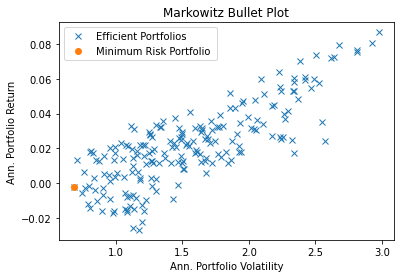

In [26]:
# Below is the plot of the efficient frontier
plt.figure()
plt.plot(fansrisk,fansrtn,'x',label = "Efficient Portfolios")
plt.plot(tf[1],tf[0],'o',label = "Minimum Risk Portfolio ")
plt.xlabel('Ann. Portfolio Volatility')
plt.ylabel('Ann. Portfolio Return')
plt.title('Markowitz Bullet Plot')
plt.legend(loc="upper left")

# put on a mark on the optimal portfolio based on variance

plt.show()

## Conclusion
The platform effectively creates a a system to allow the tester to create an asset bound estimator,
The user can then input their answers and an estimated bound for the ETF are created. 
Looking further , we can upgrade the code by including a limit on risk. 
We can aslo further give the user an option to create their own filters for the ETFs.
For the selected ETFs, and we effectively generate all possible portfolios from -100% to 100%.
